# Загрузка данных

In [55]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
import seaborn as sns

In [3]:
df_m2_geo = pd.read_csv ('df_m2_geo.csv', low_memory=False)

In [11]:
df_m2_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108728 entries, 0 to 108727
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   salary_from_log         108728 non-null  float64
 1   experience_ord          108728 non-null  int64  
 2   role_name               108728 non-null  object 
 3   schedule_id             108728 non-null  object 
 4   employment_id           108728 non-null  object 
 5   economic_region         108728 non-null  object 
 6   geo_available           108728 non-null  int64  
 7   region_name             108728 non-null  object 
 8   address.city_new        108728 non-null  object 
 9   lat_sin                 95283 non-null   float64
 10  lat_cos                 95283 non-null   float64
 11  lon_sin                 95283 non-null   float64
 12  lon_cos                 95283 non-null   float64
 13  geohash_4               108728 non-null  object 
 14  geohash_5           

# Catboost M2.1

In [5]:
groups = df_m2_geo['region_name']

In [7]:
results = []

In [9]:
gkf = GroupKFold(n_splits=5)

In [11]:
models_config = {
    "M2.1.0_structure": {  # baseline: только структурные признаки
        "cat": ['role_name', 'schedule_id', 'employment_id','experience_ord'],
        "num": []
    }
    ,
    "M2.1.1_region": {  # добавляем экономический регион, регион и город
        "cat": ['role_name', 'schedule_id', 'employment_id', 'economic_region', 'region_name', 'address.city_new','experience_ord'],
        "num": []
    }
    ,
    "M2.1.2_sincos": {  # добавляем синусы/косинусы координат
        "cat": ['role_name', 'schedule_id', 'employment_id', 'economic_region', 'region_name', 'address.city_new','experience_ord'],
        "num": ['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos', 'geo_available']
    }
    ,
    "M2.1.3_geohash": {  # добавляем geohash
        "cat": ['role_name', 'schedule_id', 'employment_id', 'economic_region', 'region_name', 'address.city_new', 'experience_ord',
          'geohash_4', 'geohash_5', 'geohash_6'],
        "num": [ 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos','geo_available']
    }
    ,
    "M2.1.4_distance": {  # добавляем distance_to_reg_center и distance_missing
        "cat": ['role_name', 'schedule_id', 'employment_id', 'economic_region', 'region_name', 'address.city_new', 'experience_ord',
          'geohash_4', 'geohash_5', 'geohash_6'],
        "num": [ 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos','geo_available','distance_to_reg_center', 'distance_missing']
    }
}

In [13]:
catboost_params = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "loss_function": "RMSE",
    "task_type": "GPU",
    "devices": "0",
    "gpu_ram_part": 0.8,
    "random_seed": 42,
    "verbose": 100
}

In [15]:
for model_name, config in tqdm(models_config.items(), desc="Models", position=0):

    print(f"\nTraining {model_name}...")

    features = config["cat"] + config["num"]
    X = df_m2_geo[features]
    y = df_m2_geo['salary_from_log']

    rmse_scores = []
    r2_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(
        tqdm(gkf.split(X, y, groups), desc=f"Folds ({model_name})", position=1, leave=False)
    ):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**catboost_params)

        model.fit(
            X_train, y_train,
            cat_features=config["cat"],
            eval_set=(X_val, y_val),
            verbose=0
        )

        preds = model.predict(X_val)

        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))

    results.append({
        "model": model_name,
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores),
        "R2_mean": np.mean(r2_scores)
    })

Models:   0%|          | 0/5 [00:00<?, ?it/s]


Training M2.1.0_structure...



Folds (M2.1.0_structure): 0it [00:00, ?it/s]
Folds (M2.1.0_structure): 1it [01:00, 60.16s/it]
Folds (M2.1.0_structure): 2it [01:25, 39.68s/it]
Folds (M2.1.0_structure): 3it [01:49, 32.53s/it]
Folds (M2.1.0_structure): 4it [02:15, 29.76s/it]
Folds (M2.1.0_structure): 5it [02:40, 28.30s/it]
Models:  20%|██        | 1/5 [02:40<10:43, 160.76s/it]


Training M2.1.1_region...



Folds (M2.1.1_region): 0it [00:00, ?it/s]
Folds (M2.1.1_region): 1it [00:35, 35.96s/it]
Folds (M2.1.1_region): 2it [01:11, 35.60s/it]
Folds (M2.1.1_region): 3it [01:46, 35.43s/it]
Folds (M2.1.1_region): 4it [02:21, 35.34s/it]
Folds (M2.1.1_region): 5it [02:59, 36.14s/it]
Models:  40%|████      | 2/5 [05:40<08:35, 171.68s/it]

...


Folds (M2.1.2_sincos): 0it [00:00, ?it/s]
Folds (M2.1.2_sincos): 1it [00:50, 50.06s/it]
Folds (M2.1.2_sincos): 2it [01:38, 48.90s/it]
Folds (M2.1.2_sincos): 3it [02:21, 46.57s/it]
Folds (M2.1.2_sincos): 4it [03:04, 45.18s/it]
Folds (M2.1.2_sincos): 5it [03:47, 44.35s/it]
Models:  60%|██████    | 3/5 [09:27<06:34, 197.35s/it]


Training M2.1.3_geohash...



Folds (M2.1.3_geohash): 0it [00:00, ?it/s]
Folds (M2.1.3_geohash): 1it [00:49, 49.12s/it]
Folds (M2.1.3_geohash): 2it [01:38, 49.20s/it]
Folds (M2.1.3_geohash): 3it [02:26, 48.85s/it]
Folds (M2.1.3_geohash): 4it [03:47, 61.49s/it]
Folds (M2.1.3_geohash): 5it [04:35, 56.68s/it]
Models:  80%|████████  | 4/5 [14:03<03:48, 228.34s/it]


Training M2.1.4_distance...



Folds (M2.1.4_distance): 0it [00:00, ?it/s]
Folds (M2.1.4_distance): 1it [00:51, 51.94s/it]
Folds (M2.1.4_distance): 2it [01:42, 50.87s/it]
Folds (M2.1.4_distance): 3it [02:31, 50.23s/it]
Folds (M2.1.4_distance): 4it [03:21, 50.18s/it]
Folds (M2.1.4_distance): 5it [04:12, 50.25s/it]
Models: 100%|██████████| 5/5 [18:15<00:00, 219.18s/it]


# Анализ метрик

In [16]:
results_df_geo = pd.DataFrame(results).sort_values("RMSE_mean")
results_df_geo

,model,RMSE_mean,RMSE_std,R2_mean
4,M2.1.4_distance,0.324853,0.025458,0.448371
3,M2.1.3_geohash,0.329835,0.023612,0.430862
2,M2.1.2_sincos,0.334808,0.031176,0.415554
1,M2.1.1_region,0.341987,0.035359,0.390470
0,M2.1.0_structure,0.346272,0.044376,0.376725


In [35]:
results_df = pd.DataFrame(results)

# baseline
baseline_rmse = results_df.loc[results_df["model"]=="M2.1.0_structure","RMSE_mean"].values[0]
baseline_r2 = results_df.loc[results_df["model"]=="M2.1.0_structure","R2_mean"].values[0]

# улучшения относительно baseline
results_df["RMSE_improvement_%"] = (baseline_rmse - results_df["RMSE_mean"]) / baseline_rmse * 100
results_df["R2_gain"] = results_df["R2_mean"] - baseline_r2

results_df = results_df.sort_values("model")

print(results_df)

              model  RMSE_mean  RMSE_std   R2_mean  RMSE_improvement_%  \
0  M2.1.0_structure   0.346272  0.044376  0.376725            0.000000   
1     M2.1.1_region   0.341987  0.035359  0.390470            1.237623   
2     M2.1.2_sincos   0.334808  0.031176  0.415554            3.310803   
3    M2.1.3_geohash   0.329835  0.023612  0.430862            4.746741   
4   M2.1.4_distance   0.324853  0.025458  0.448371            6.185593   

    R2_gain  
0  0.000000  
1  0.013745  
2  0.038829  
3  0.054137  
4  0.071646  


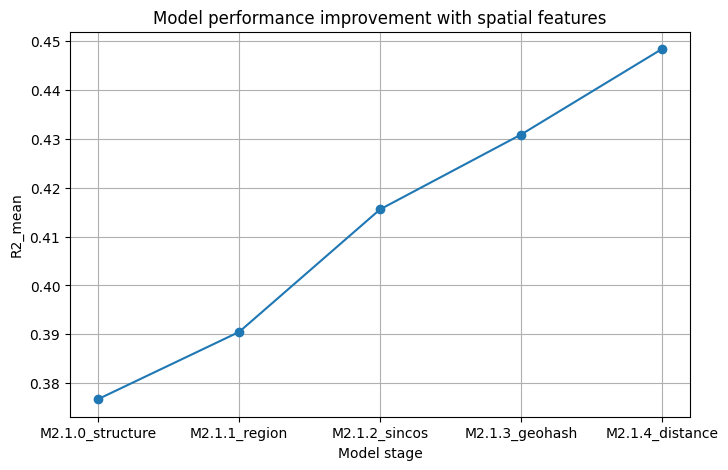

In [49]:
plt.figure(figsize=(8,5))

plt.plot(results_df["model"], results_df["R2_mean"], marker="o")
plt.title("Model performance improvement with spatial features")
plt.xlabel("Model stage")
plt.ylabel("R2_mean")

plt.grid(True)
plt.show()

In [37]:
#Сохраним лучшую модель
best_model = model
best_features = models_config['M2.1.4_distance']["cat"] + \
                models_config['M2.1.4_distance']["num"]

In [39]:
# Конфиг лучшей модели
best_config = models_config['M2.1.4_distance']
features = best_config["cat"] + best_config["num"]

X_final = df_m2_geo[features]
y_final = df_m2_geo['salary_from_log']

# Обучение на всем датасете
best_model = CatBoostRegressor(**catboost_params)
best_model.fit(X_final, y_final, cat_features=best_config["cat"], verbose=0)

# Предсказания
y_pred = best_model.predict(X_final)

# Метрики in-sample
rmse = np.sqrt(mean_squared_error(y_final, y_pred))
mae = mean_absolute_error(y_final, y_pred)
r2 = r2_score(y_final, y_pred)

# Вывод метрик
best_model_metrics = pd.DataFrame([{
    'Model': 'M2.1.4_distance (best)',
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}])
print(best_model_metrics.round(4))

                    Model    RMSE     MAE      R2
0  M2.1.4_distance (best)  0.2662  0.2022  0.6525


# Feature Importance и SHAP

C:\Users\Angelina\AppData\Local\Temp\ipykernel_21732\3803504232.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


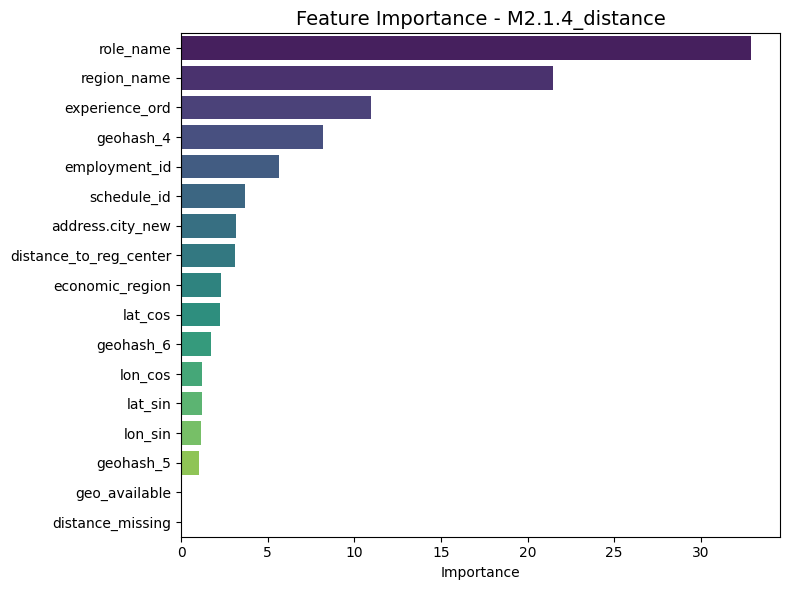

In [57]:
#Строим график feature_importance

feature_importance = best_model.get_feature_importance(type='FeatureImportance')

fi_df = pd.DataFrame({
    'feature': best_model.feature_names_,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=fi_df,
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('Feature Importance - M2.1.4_distance', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [63]:
pool = Pool(
    X_final,
    cat_features=best_config["cat"]
)

shap_values = best_model.get_feature_importance(
    pool,
    type='ShapValues'
)

# убираем bias (последний столбец)
shap_values = shap_values[:, :-1]

C:\Users\Angelina\AppData\Local\Temp\ipykernel_21732\952770922.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


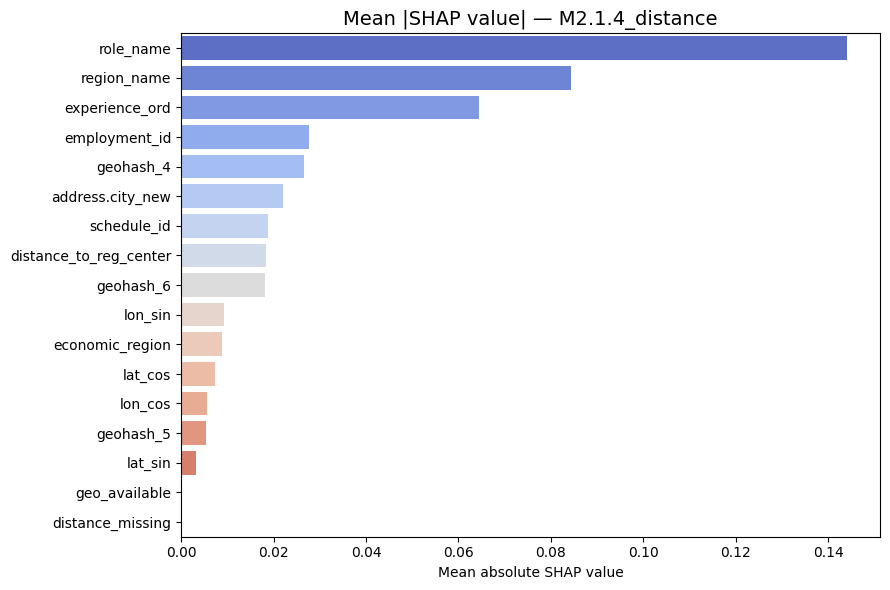

In [65]:
shap_df = pd.DataFrame(
    np.abs(shap_values).mean(axis=0),
    index=best_model.feature_names_,
    columns=['mean_abs_shap']
).sort_values('mean_abs_shap', ascending=False)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=shap_df.reset_index(),
    x='mean_abs_shap',
    y='index',
    palette='coolwarm'
)

plt.title('Mean |SHAP value| — M2.1.4_distance', fontsize=14)
plt.xlabel('Mean absolute SHAP value')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [79]:
fi_df.to_csv("feature_importance_m21_4.csv", index=False)

In [67]:
#Задаём группы признаков
structure_features = [
    'role_name',
    'schedule_id',
    'employment_id',
    'experience_ord'
]

region_features = [
    'economic_region',
    'region_name',
    'address.city_new'
]

geohash_features = [
    'geohash_4',
    'geohash_5',
    'geohash_6'
]

distance_features = [
    'distance_to_reg_center',
    'distance_missing'
]

coord_features = [
    'lat_sin',
    'lat_cos',
    'lon_sin',
    'lon_cos',
    'geo_available'
]

In [69]:
#Считаем вклад групп
total_shap = shap_df['mean_abs_shap'].sum()

group_importance = {
    'Structure': shap_df.loc[
        shap_df.index.isin(structure_features),
        'mean_abs_shap'
    ].sum() / total_shap,

    'Region': shap_df.loc[
        shap_df.index.isin(region_features),
        'mean_abs_shap'
    ].sum() / total_shap,

    'Geo - Geohash': shap_df.loc[
        shap_df.index.isin(geohash_features),
        'mean_abs_shap'
    ].sum() / total_shap,

    'Geo - Distance': shap_df.loc[
        shap_df.index.isin(distance_features),
        'mean_abs_shap'
    ].sum() / total_shap,

    'Geo - Coordinates': shap_df.loc[
        shap_df.index.isin(coord_features),
        'mean_abs_shap'
    ].sum() / total_shap,
}

group_df = pd.DataFrame.from_dict(
    group_importance,
    orient='index',
    columns=['share']
).sort_values('share', ascending=False)

group_df

,share
Structure,0.549133
Region,0.248523
Geo - Geohash,0.108033
Geo - Coordinates,0.054814
Geo - Distance,0.039496


C:\Users\Angelina\AppData\Local\Temp\ipykernel_21732\514888348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


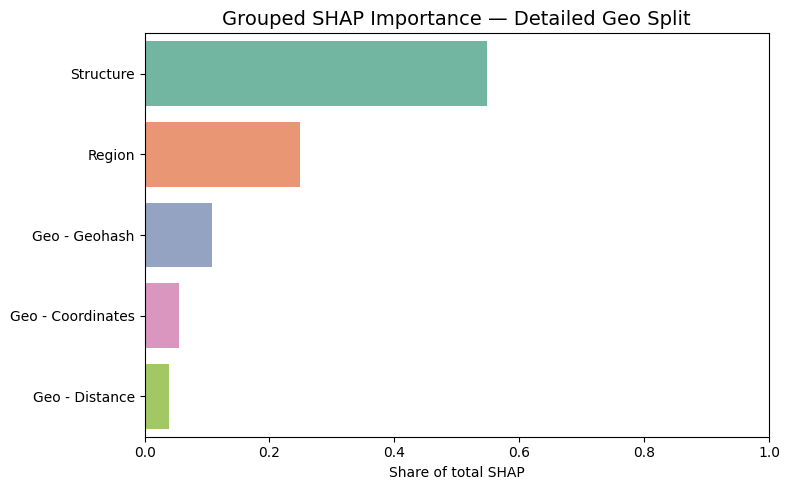

In [71]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=group_df.reset_index(),
    x='share',
    y='index',
    palette='Set2'
)

plt.title('Grouped SHAP Importance — Detailed Geo Split', fontsize=14)
plt.xlabel('Share of total SHAP')
plt.ylabel('')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

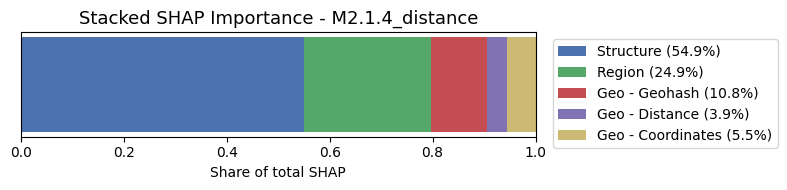

In [81]:
colors = {
    'Structure': '#4C72B0',
    'Region': '#55A868',
    'Geo - Geohash': '#C44E52',
    'Geo - Distance': '#8172B3',
    'Geo - Coordinates': '#CCB974'
}

plt.figure(figsize=(8, 2))

left = 0

for group, value in group_importance.items():
    plt.barh(
        y='Model',
        width=value,
        left=left,
        color=colors[group],
        label=f"{group} ({value:.1%})"
    )
    left += value

plt.xlim(0, 1)
plt.title('Stacked SHAP Importance - M2.1.4_distance', fontsize=13)
plt.xlabel('Share of total SHAP')
plt.yticks([])
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

In [83]:
final_results = pd.DataFrame({

    "Model": [
        "M1.1",
        "M1.2",
        "M2.1.0",
        "M2.1.4"
    ],

    "Algorithm": [
        "OLS",
        "Ridge",
        "CatBoost",
        "CatBoost"
    ],

    "Features": [
        "Structural",
        "Structural",
        "Structural",
        "Structural + Spatial"
    ],

    "CV_RMSE": [
        0.3668,
        0.3668,
        0.3463,
        0.3249
    ],

    "CV_R2": [
        0.347,
        0.347,
        0.377,
        0.448
    ]

})

print(final_results)

    Model Algorithm              Features  CV_RMSE  CV_R2
0    M1.1       OLS            Structural   0.3668  0.347
1    M1.2     Ridge            Structural   0.3668  0.347
2  M2.1.0  CatBoost            Structural   0.3463  0.377
3  M2.1.4  CatBoost  Structural + Spatial   0.3249  0.448


C:\Users\Angelina\AppData\Local\Temp\ipykernel_21732\1233625420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


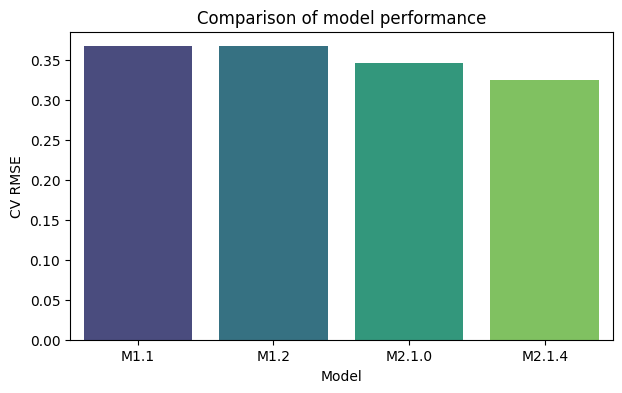

In [85]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=final_results,
    x="Model",
    y="CV_RMSE",
    palette="viridis"
)

plt.title("Comparison of model performance")
plt.ylabel("CV RMSE")
plt.xlabel("Model")

plt.show()